In [1]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
from sklearn.feature_extraction.text import TfidfVectorizer
from PIL import Image
import requests
from io import BytesIO
import pytz
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse, parse_qs
from sklearn.model_selection import GridSearchCV

### Définition des fonctions qui serviront à explorer le dataset puis le traiter

In [2]:
# Définition d'une fonction pour identifier les duplicatas (sans prendre en compte les NaN):

def duplicata(data, col) :
    for i in data[(data[col].duplicated() == True) & (data[col].isna() == False)].index :
        print(data.iloc[i][col])
        #print("\n")
    return

In [3]:
# Définition d'une fonction pour calculer des ratios (dans le but d'ajouter des features aux modèles) :

def ratio(data, col_num, col_denum) :
    return np.array(data[col_num]/data[col_denum])

## Exploration initiale du dataset (Shortcat)

In [4]:
# Création du dataframe brut des données et aperçu

raw_shortcat = pd.read_csv("videos_shortcat.csv")

display(raw_shortcat)

,title,description,tags,has_caption,channel,video_url,views,likes,comments,publishedAt,duration_seconds
0,I Win ❌ Everyone else LOST ✅ | Mario Kart 8 De...,madrid drive with gyrodos. i hit my teammate a...,NaN,False,Shortcat,https://www.youtube.com/watch?v=rbjW0J6Ep1M,68603,3698,107,2025-05-14T16:01:31Z,31
1,The Competitive Mario Kart Team you've all bee...,You've all been asking and it's finally here! ...,NaN,True,Shortcat,https://www.youtube.com/watch?v=ioPcBtbydS4,168456,9828,657,2025-05-13T18:01:48Z,1817
2,#1 DUMBEST Cheese Land 🧀 Race of ALL Time | Ma...,"bagging vs frontrunning, double shock dodge on...",NaN,False,Shortcat,https://www.youtube.com/watch?v=ldQUM0IIBfw,417446,23114,224,2025-05-12T17:52:49Z,80
3,My Secret Goal in Competitive Mario Kart 8 Deluxe,I want to improve my skills and reach 6000 MMR...,NaN,True,Shortcat,https://www.youtube.com/watch?v=IST7o-rUIOc,180457,9817,774,2025-05-11T16:00:22Z,1940
4,The HIGHEST Level of Competitive Mario Kart 8 ...,"Today I'm at 5000+ MMR for the first time, aga...",NaN,True,Shortcat,https://www.youtube.com/watch?v=Kk0vH3xSKkI,202324,9243,534,2025-05-10T16:00:34Z,1834
...,...,...,...,...,...,...,...,...,...,...,...
449,EVERY Shortcut on YOSHI CIRCUIT 150cc | Mario ...,NaN,NaN,False,Shortcat,https://www.youtube.com/watch?v=JlAeYQQJfQ0,1377523,87912,301,2023-04-11T13:00:21Z,58
450,EVERY Shortcut on DK SUMMIT 150cc | Mario Kart...,NaN,NaN,False,Shortcat,https://www.youtube.com/watch?v=GJCLFOFlSv0,1525157,104203,312,2023-04-10T18:41:16Z,59
451,EVERY Shortcut on BIG BLUE 150cc | Mario Kart ...,NaN,NaN,False,Shortcat,https://www.youtube.com/watch?v=IRH789NbyGk,1776234,118546,437,2023-04-08T13:00:11Z,52
452,"Mario Kart 8 Deluxe, except I wait 10 seconds ...","...8, 9, 10.\nAnd now, he will try.\n\nHow to ...",NaN,True,Shortcat,https://www.youtube.com/watch?v=wubcV46XBcM,314553,7297,591,2023-04-07T00:34:10Z,1097


In [5]:
# Premières explorations rapides

print(raw_shortcat.info())
print("\n")
display(raw_shortcat.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             454 non-null    object
 1   description       446 non-null    object
 2   tags              2 non-null      object
 3   has_caption       454 non-null    bool  
 4   channel           454 non-null    object
 5   video_url         454 non-null    object
 6   views             454 non-null    int64 
 7   likes             454 non-null    int64 
 8   comments          454 non-null    int64 
 9   publishedAt       454 non-null    object
 10  duration_seconds  454 non-null    int64 
dtypes: bool(1), int64(4), object(6)
memory usage: 36.0+ KB
None




,title,description,tags,has_caption,channel,video_url,views,likes,comments,publishedAt,duration_seconds
count,454,446,2,454,454,454,4.540000e+02,454.000000,454.000000,454,454.000000
unique,453,441,2,2,1,454,NaN,NaN,NaN,454,NaN
top,Here's how to WIN on Cheese Land | Mario Kart ...,red shells are very powerful in mk8dx. but the...,"['female villager', 'neo bowser city']",False,Shortcat,https://www.youtube.com/watch?v=MjoswRuHxmw,NaN,NaN,NaN,2023-03-31T18:32:30Z,NaN
freq,2,2,1,318,454,1,NaN,NaN,NaN,1,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,1.594962e+06,79743.656388,647.843612,NaN,683.416300
std,NaN,NaN,NaN,NaN,NaN,NaN,2.097191e+06,99685.601448,664.051528,NaN,1194.479275
min,NaN,NaN,NaN,NaN,NaN,NaN,6.860300e+04,3698.000000,79.000000,NaN,22.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,5.217495e+05,17587.750000,244.750000,NaN,51.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.693120e+05,47939.500000,492.000000,NaN,58.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,1.615088e+06,91609.000000,814.500000,NaN,1482.500000


In [6]:
# Identification des duplicatas de titres et descriptions

duplicata(raw_shortcat, "title")
print("\n")
duplicata(raw_shortcat, "description")

Here's how to WIN on Cheese Land | Mario Kart 8 Deluxe


red shells are very powerful in mk8dx. but the blue shell is also powerful, and you want to avoid it. this is how to steal 1st place and win, by being in 2nd the whole race!
shortcat mii teddy buggy roller tires mk8dx
sky garden, shortalien, hit, bumped off, coins, star, bullet bill, comeback, bagging, 1st, win
tutorial: fastest way to charge mini turbos with delayed drift and soft drifting in mk8dx on 150cc and 200cc
is bagging luck or skill? bagging (sandbagging) involves the bullet bill, star, golden mushroom, mushrooms, or shock (lightning) to make a comeback
tutorial: how to bag / do the bullet extension by bagging on cheese land 150cc in mk8dx


Après vérification rapide dans le fichier csv (en utilisant la recherche Ctrl+F), nous vérifions que les vidéos sont bien toutes différentes malgré les duplicatas dans les titres ou descriptions.

## Préparation des données et feature engineering

### Premier traitement

In [7]:
df_test = raw_shortcat[["views", "likes", "comments", "duration_seconds"]].copy()
df_test

,views,likes,comments,duration_seconds
0,68603,3698,107,31
1,168456,9828,657,1817
2,417446,23114,224,80
3,180457,9817,774,1940
4,202324,9243,534,1834
...,...,...,...,...
449,1377523,87912,301,58
450,1525157,104203,312,59
451,1776234,118546,437,52
452,314553,7297,591,1097


In [8]:
df_test["like/view"] = ratio(df_test, "likes", "views")
df_test["comment/view"] = ratio(df_test, "comments", "views")
df_test

,views,likes,comments,duration_seconds,like/view,comment/view
0,68603,3698,107,31,0.053904,0.001560
1,168456,9828,657,1817,0.058342,0.003900
2,417446,23114,224,80,0.055370,0.000537
3,180457,9817,774,1940,0.054401,0.004289
4,202324,9243,534,1834,0.045684,0.002639
...,...,...,...,...,...,...
449,1377523,87912,301,58,0.063819,0.000219
450,1525157,104203,312,59,0.068323,0.000205
451,1776234,118546,437,52,0.066740,0.000246
452,314553,7297,591,1097,0.023198,0.001879


#### Vérification de la pertinence des données :

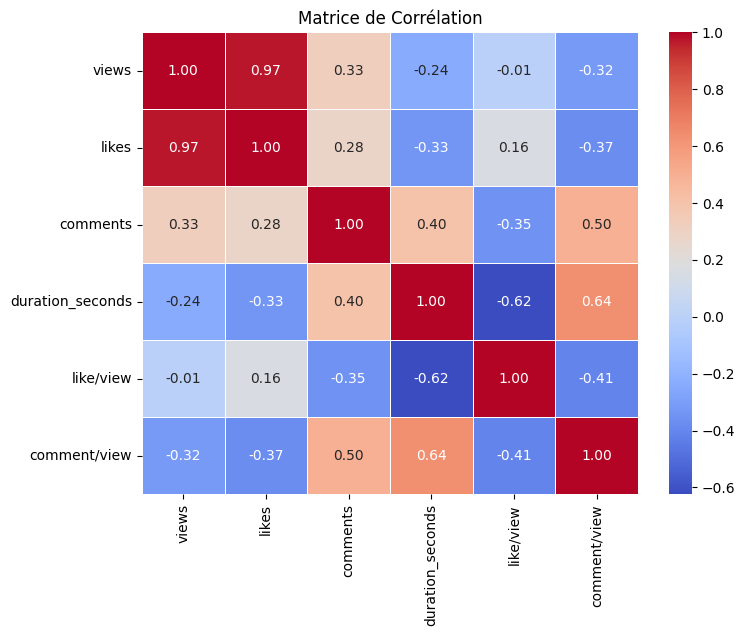

In [9]:
# Calcul de la matrice de corrélation
correlation_matrix = df_test.corr()

# Affichage de la matrice de corrélation avec seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice de Corrélation')
plt.show()

Ici, on se rend compte que les features choisies ne sont absoluement pas pertinentes : elles sont en majorité très corrélées soit à views, soit entre elles. Cela s'explique par le fait que les stats d'une vidéos se construisent autour des vues, ce serait donc plus pertinent de les prédire au même titre qu'on le fait pour elles.

## Nouveau feature engineering

In [43]:
df = raw_shortcat.copy()

In [44]:
# Prétraitement temporel (fuseau Canada, Toronto UTC-5)
df['publishedAt'] = pd.to_datetime(df['publishedAt'], utc=True)
df['publishedAt'] = df['publishedAt'].dt.tz_convert('America/Toronto')

# Ajouter une colonne pour distinguer les Shorts (la limite actuelle sur YouTube est de 3 minutes, donc 180 secondes)
df['is_short'] = df['duration_seconds'] <= 180

# Filtrer les vidéos publiées jusqu'au 31 janvier 2025
cutoff_date = pd.Timestamp("2025-01-31", tz='America/Toronto')
df = df[df['publishedAt'] <= cutoff_date]

In [45]:
# Slots horaires
def get_time_slot(hour):
    if 0 <= hour < 6:
        return "night"
    elif 6 <= hour < 10:
        return "morning"
    elif 10 <= hour < 14:
        return "midday"
    elif 14 <= hour < 18:
        return "afternoon"
    else:
        return "evening"

# Extraction des features temporelles
df['weekday'] = df['publishedAt'].dt.weekday
df['hour'] = df['publishedAt'].dt.hour
df['month'] = df['publishedAt'].dt.month
df['time_slot'] = df['hour'].apply(get_time_slot)

In [46]:
# Features sur le titre et la description

emoji_pattern = re.compile(r"[\U0001F300-\U0001F6FF\U0001F900-\U0001F9FF]", flags=re.UNICODE)
url_pattern = re.compile(r'https?://\S+')

df['title_len'] = df['title'].str.len()
df['emoji_count'] = df['title'].apply(lambda x: len(emoji_pattern.findall(x)))
df['uppercase_ratio'] = df['title'].apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
df['exclamation_count'] = df['title'].str.count('!')
df['desc_len'] = df['description'].fillna('').str.len()
df['link_count'] = df['description'].fillna('').apply(lambda x: len(url_pattern.findall(x)))
df['question_count'] = df['description'].fillna('').str.count('\?')

In [47]:
# Traitement de la durée

df['log_duration'] = np.log1p(df['duration_seconds'])

In [48]:
# Miniature : couleur dominante

def extract_dominant_color(url):
    try:
        resp = requests.get(url, timeout=5)
        img = Image.open(BytesIO(resp.content)).convert('RGB')
        img = img.resize((50, 50))
        arr = np.array(img).reshape(-1, 3)
        return tuple(arr.mean(axis=0))
    except Exception:
        return (0, 0, 0)

df['thumbnail_url'] = df['video_url'].apply(lambda x: x.replace("watch?v=", "vi/").split("/")[-1] + "/hqdefault.jpg")
df[['thumb_r', 'thumb_g', 'thumb_b']] = df['thumbnail_url'].apply(lambda x: pd.Series(extract_dominant_color(f"https://img.youtube.com/vi/{x}")))

In [49]:
# TF-IDF sur titre + description

tfidf = TfidfVectorizer(max_features=100, stop_words='english')
corpus = (df['title'].fillna('')).tolist()
tfidf_matrix = tfidf.fit_transform(corpus)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f'tfidf_{i}' for i in range(tfidf_matrix.shape[1])])
df = pd.concat([df.reset_index(drop=True), tfidf_df], axis=1)

In [50]:
df_shorts = df[df['is_short']].copy()
df_longs = df[~df['is_short']].copy()

In [51]:
df

,title,description,tags,has_caption,channel,video_url,views,likes,comments,publishedAt,...,tfidf_90,tfidf_91,tfidf_92,tfidf_93,tfidf_94,tfidf_95,tfidf_96,tfidf_97,tfidf_98,tfidf_99
0,EVERYTHING I Want for MARIO KART WORLD | Wish ...,The new Mario Kart game for the Nintendo Switc...,NaN,True,Shortcat,https://www.youtube.com/watch?v=MLPacB2Op44,698234,24244,3809,2025-01-29 12:00:26-05:00,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.960966,0.0,0.000000
1,TOP 5 Mario Kart Beginner Tips!,beginner tips for how to win more in mario kar...,NaN,False,Shortcat,https://www.youtube.com/watch?v=5kynaufsQ9Y,1004562,60371,485,2025-01-27 12:00:05-05:00,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
2,I Found My Son...,Today I found SHORTKITTY (my son) in online wo...,NaN,True,Shortcat,https://www.youtube.com/watch?v=OwlLGyHPARE,621393,20655,1346,2025-01-25 12:00:25-05:00,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
3,Mario Kart IQ Test #3 (Blue Shell Edition) | M...,mario kart iq test part 3! 150cc and 200cc mk8dx,NaN,False,Shortcat,https://www.youtube.com/watch?v=tRt3yPsMHVE,1399758,91739,686,2025-01-21 12:01:02-05:00,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
4,Going FULL Try-Hard in Competitive Mario Kart ...,Playing 12 races in Competitive MK8DX Lounge 2...,NaN,True,Shortcat,https://www.youtube.com/watch?v=Bg5K1rd8EFU,579815,16942,759,2025-01-19 12:00:09-05:00,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,EVERY Shortcut on YOSHI CIRCUIT 150cc | Mario ...,NaN,NaN,False,Shortcat,https://www.youtube.com/watch?v=JlAeYQQJfQ0,1377523,87912,301,2023-04-11 09:00:21-04:00,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.572142
392,EVERY Shortcut on DK SUMMIT 150cc | Mario Kart...,NaN,NaN,False,Shortcat,https://www.youtube.com/watch?v=GJCLFOFlSv0,1525157,104203,312,2023-04-10 14:41:16-04:00,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
393,EVERY Shortcut on BIG BLUE 150cc | Mario Kart ...,NaN,NaN,False,Shortcat,https://www.youtube.com/watch?v=IRH789NbyGk,1776234,118546,437,2023-04-08 09:00:11-04:00,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
394,"Mario Kart 8 Deluxe, except I wait 10 seconds ...","...8, 9, 10.\nAnd now, he will try.\n\nHow to ...",NaN,True,Shortcat,https://www.youtube.com/watch?v=wubcV46XBcM,314553,7297,591,2023-04-06 20:34:10-04:00,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000


## Utilisation des modèles et résultats

In [52]:
def run_pipeline(sub_df, label):
    categorical = ['time_slot']
    sub_df = pd.get_dummies(sub_df, columns=categorical, drop_first=True)

    targets = ['views', 'likes', 'comments']
    y = sub_df[targets]
    features_to_drop = ['title', 'description', 'tags', 'channel', 'video_url', 'publishedAt', 'thumbnail_url', 'is_short'] + targets
    X = sub_df.drop(columns=features_to_drop)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    param_grids = {
        'RandomForest': {'estimator__n_estimators': [50, 100]},
        'Ridge': {'estimator__alpha': [0.1, 1.0, 10.0]},
        'LightGBM': {'estimator__n_estimators': [50, 100], 'estimator__learning_rate': [0.05, 0.1]},
        'XGBoost': {'estimator__n_estimators': [50, 100], 'estimator__learning_rate': [0.05, 0.1]}
    }

    models = {
        'RandomForest': MultiOutputRegressor(RandomForestRegressor(random_state=42)),
        'Ridge': MultiOutputRegressor(Ridge()),
        'LightGBM': MultiOutputRegressor(LGBMRegressor(random_state=42)),
        'XGBoost': MultiOutputRegressor(XGBRegressor(objective='reg:squarederror', random_state=42))
    }

    results_table = []

    results = {}
    for name, model in models.items():
        grid = GridSearchCV(model, param_grids[name], cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
        rmse = np.sqrt(mean_squared_error(y_test, y_pred, multioutput='raw_values'))
        
        results_table.append({
            'Model': name,
            'Label': label,
            'MAE_views': mae[0], 'RMSE_views': rmse[0],
            'MAE_likes': mae[1], 'RMSE_likes': rmse[1],
            'MAE_comments': mae[2], 'RMSE_comments': rmse[2],
            'Best Params': grid.best_params_
        })

        # Feature importance pour LightGBM et XGBoost
        if name in ['LightGBM', 'XGBoost']:
            importances = best_model.estimators_[0].feature_importances_
            sorted_idx = np.argsort(importances)[::-1][:20]
            plt.figure(figsize=(10, 6))
            sns.barplot(x=importances[sorted_idx], y=X.columns[sorted_idx])
            plt.title(f"Top 20 Feature Importances ({name}) - {label}")
            plt.show()

        # Scatter plots
        for i, target in enumerate(targets):
            plt.figure(figsize=(5, 5))
            sns.scatterplot(x=y_test.iloc[:, i], y=y_pred[:, i], alpha=0.6)
            plt.plot([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()],
                     [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], 'r--')
            plt.xlabel(f"True {target}")
            plt.ylabel(f"Predicted {target}")
            plt.title(f"{name} Predictions vs True - {target} ({label})")
            plt.grid(True)
            plt.tight_layout()
            plt.show()

    result_df = pd.DataFrame(results_table)
    print(f"\n--- Résumé des résultats ({label}) ---")
    print(result_df[['Model', 'MAE_views', 'RMSE_views', 'MAE_likes', 'RMSE_likes', 'MAE_comments', 'RMSE_comments']])


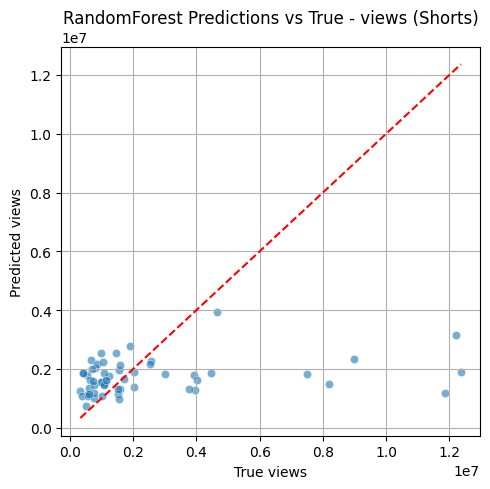

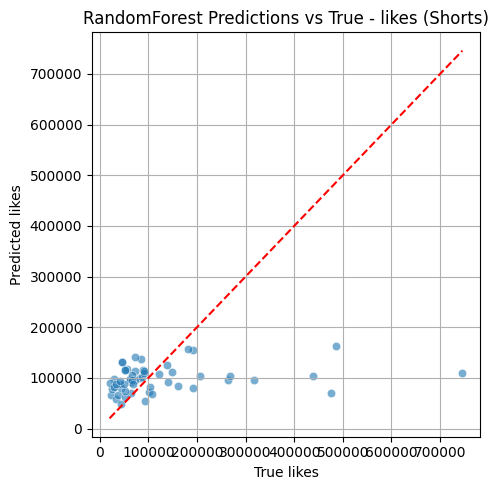

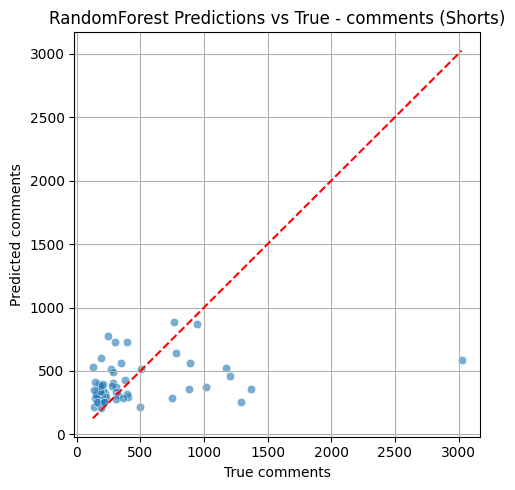

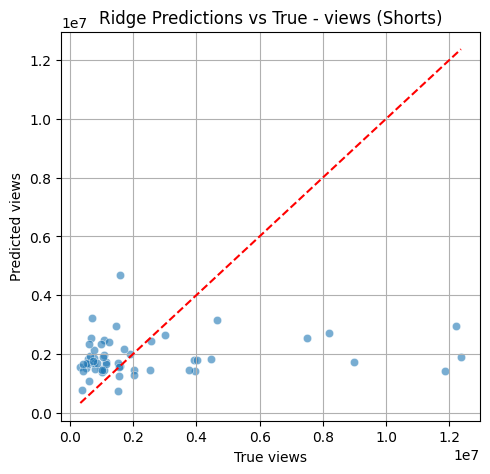

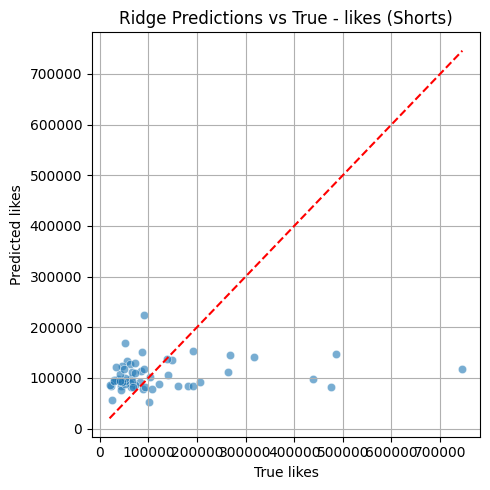

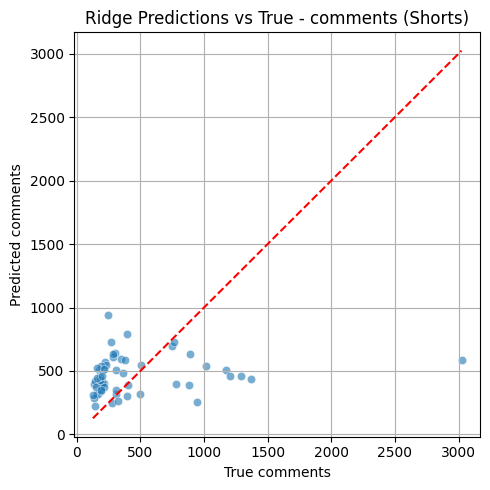

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 660
[LightGBM] [Info] Number of data points in the train set: 223, number of used features: 20
[LightGBM] [Info] Start training from score 2066487.295964
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

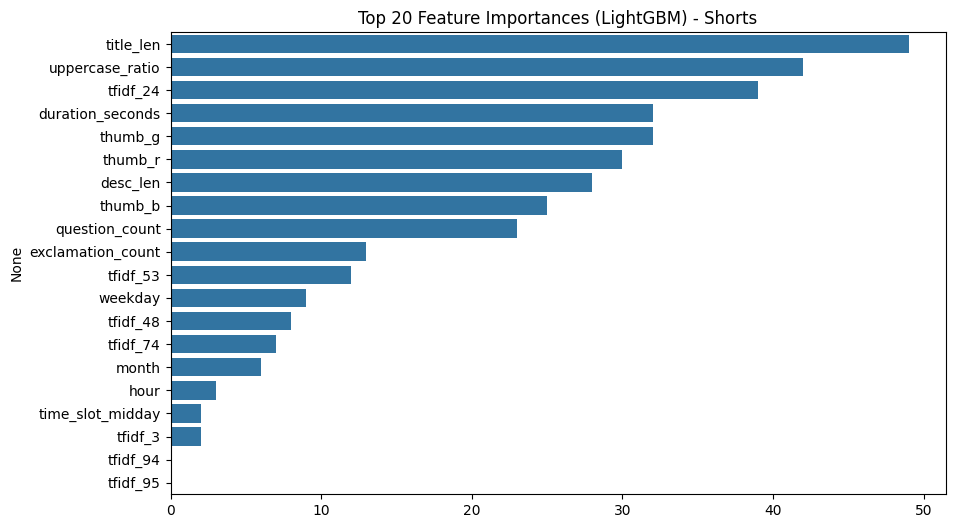

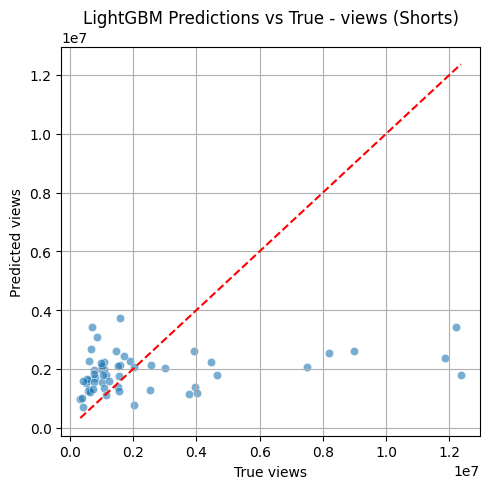

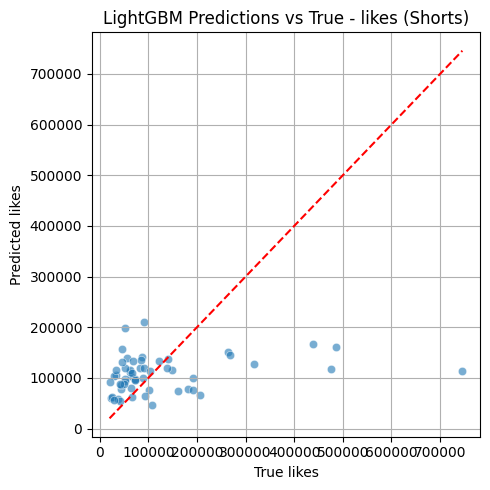

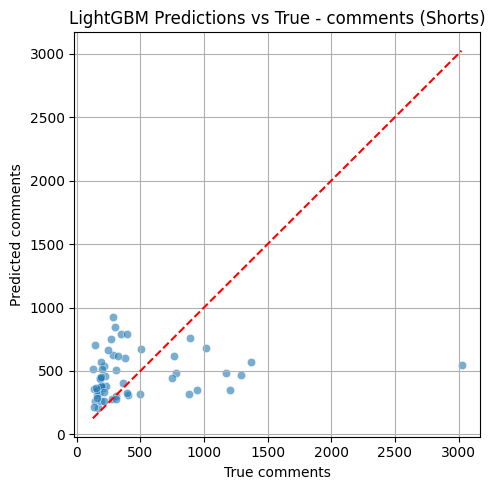

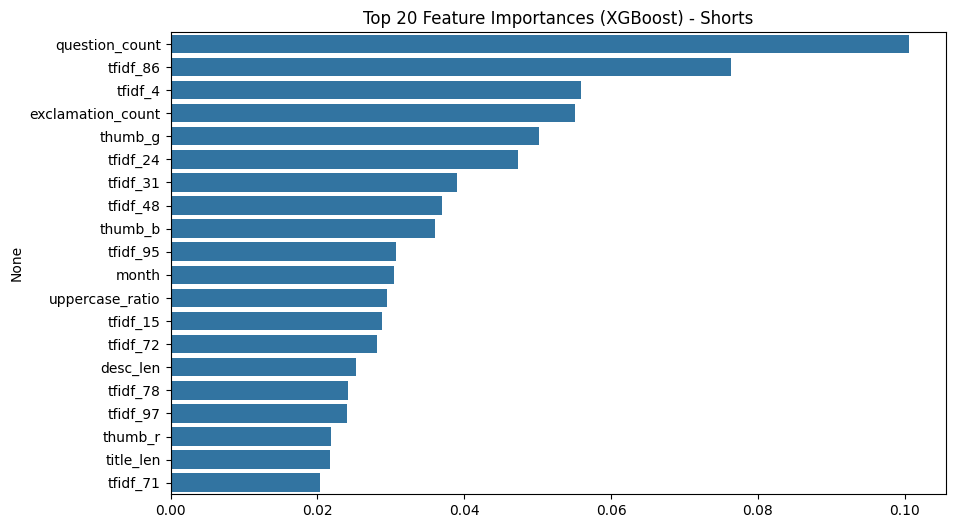

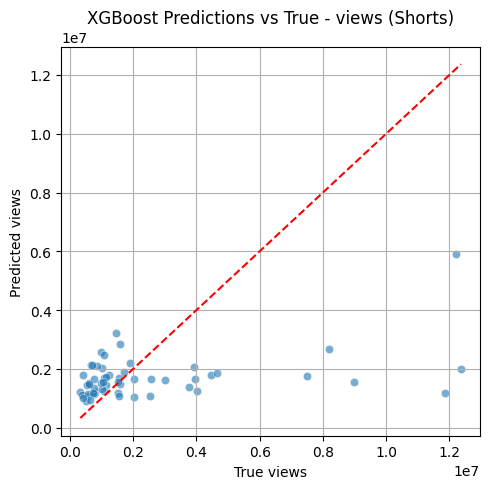

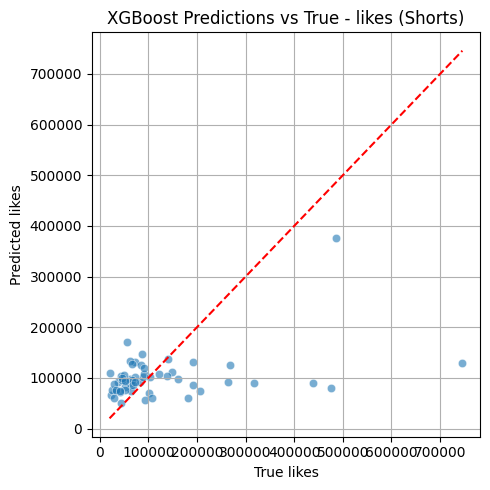

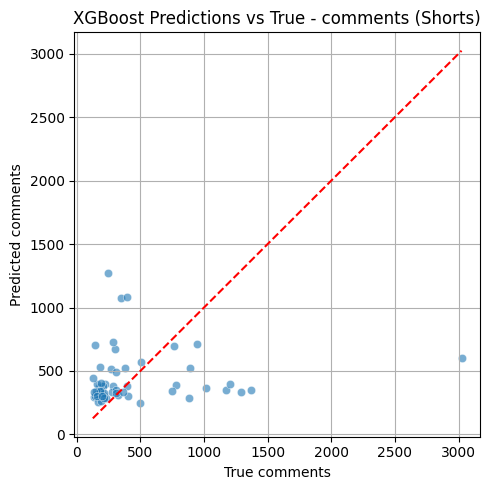


--- Résumé des résultats (Shorts) ---
          Model     MAE_views    RMSE_views     MAE_likes     RMSE_likes  \
0  RandomForest  1.663989e+06  2.952956e+06  76674.257679  133815.248190   
1         Ridge  1.809576e+06  2.976728e+06  81855.072923  134764.584749   
2      LightGBM  1.786320e+06  2.889796e+06  81477.836341  131253.467460   
3       XGBoost  1.664875e+06  2.837930e+06  74780.921875  127514.273438   

   MAE_comments  RMSE_comments  
0    268.633214     458.029092  
1    320.185306     475.301931  
2    320.651887     480.898622  
3    316.943207     501.709137  


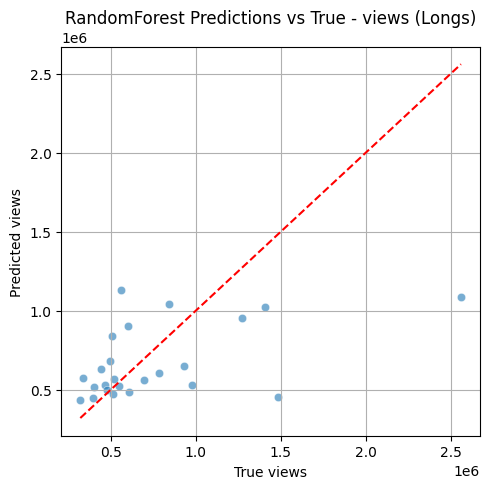

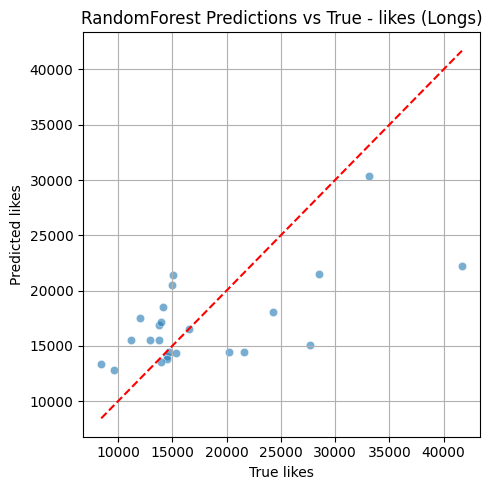

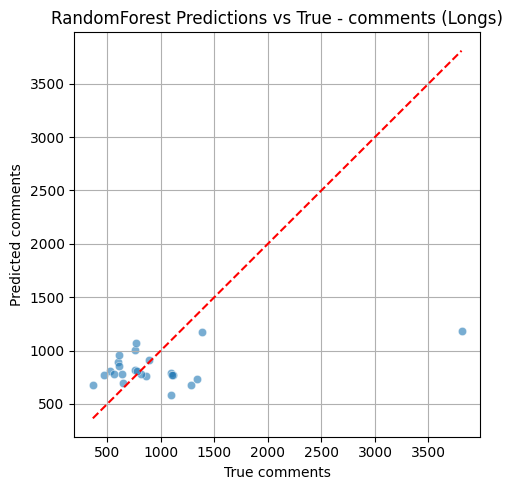

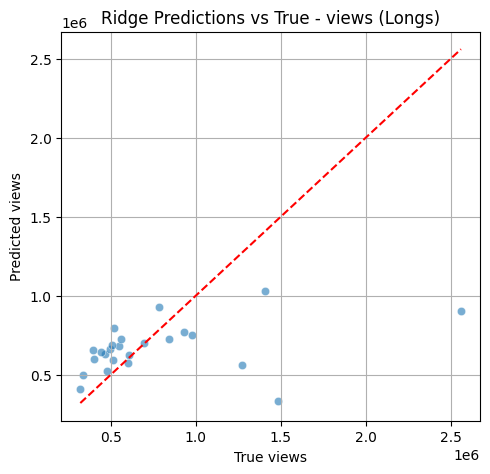

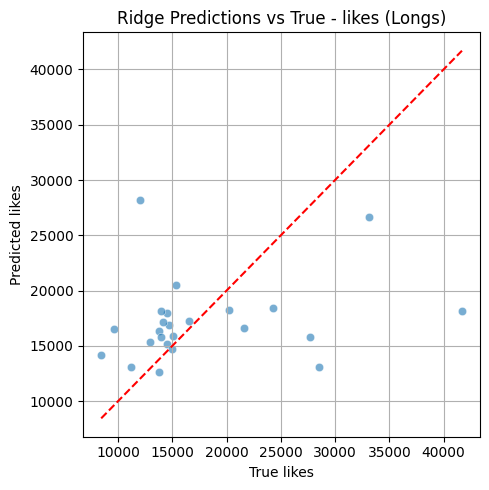

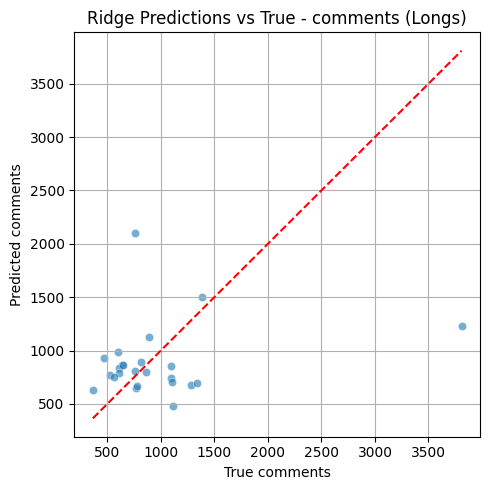

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 366
[LightGBM] [Info] Number of data points in the train set: 93, number of used features: 17
[LightGBM] [Info] Start training from score 689465.344086
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

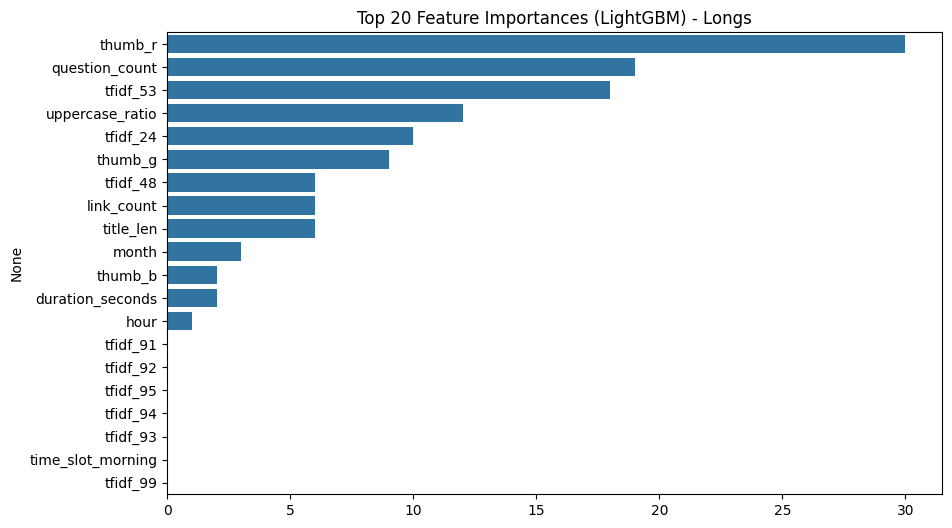

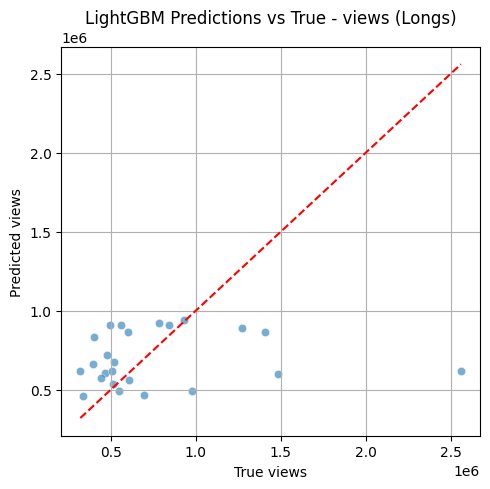

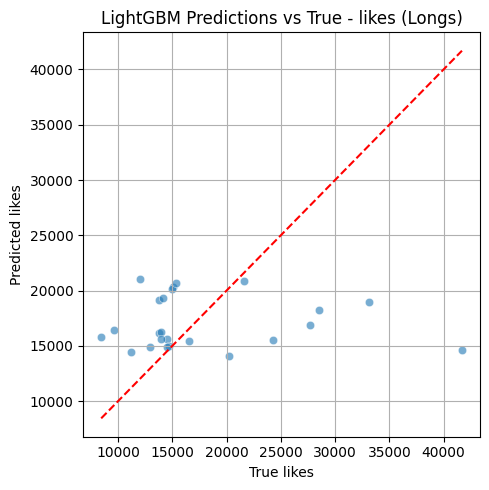

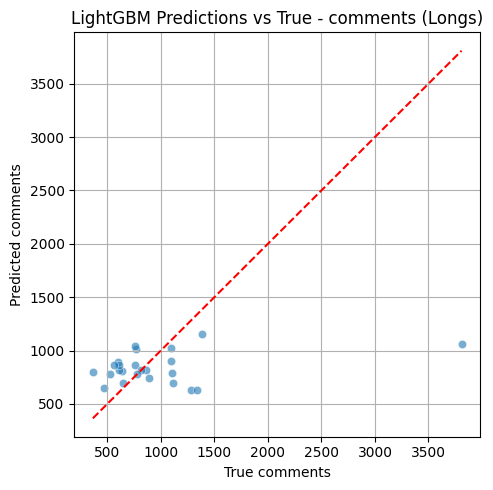

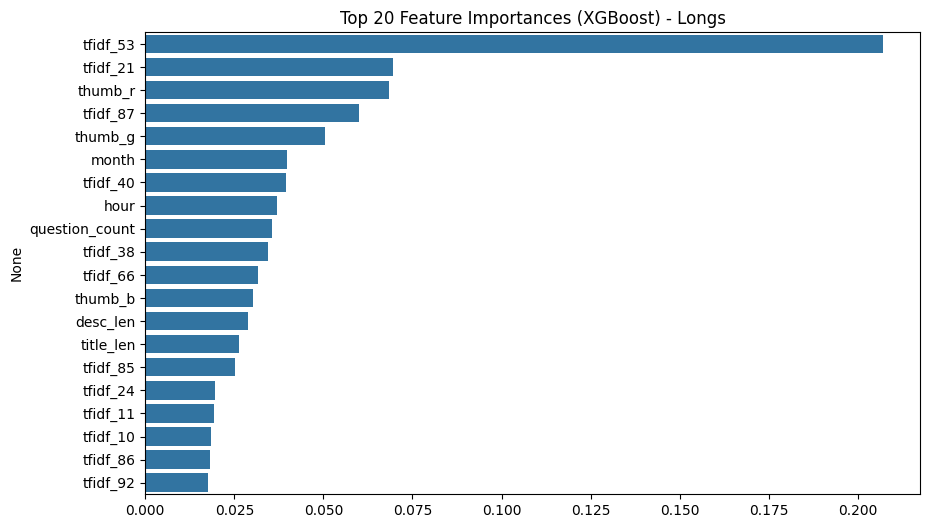

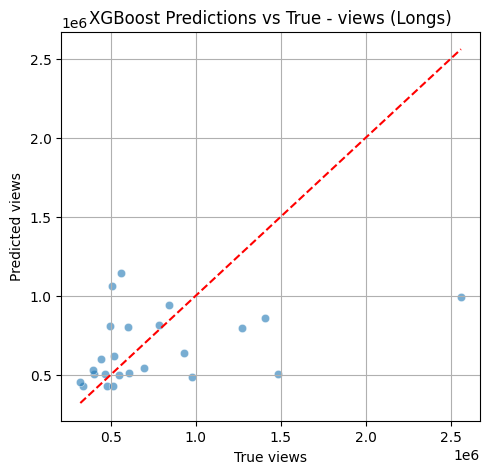

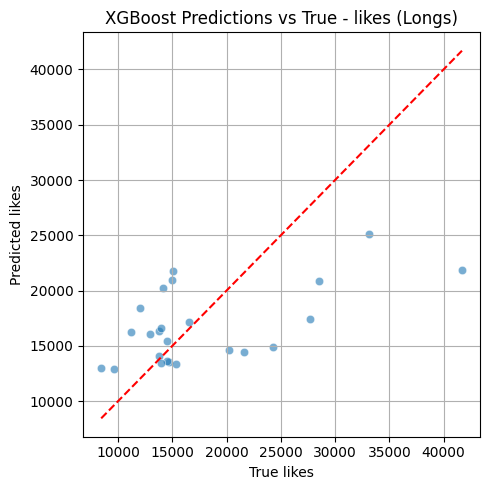

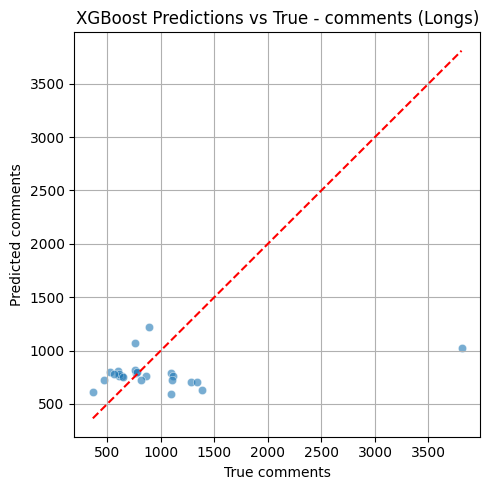


--- Résumé des résultats (Longs) ---
          Model      MAE_views     RMSE_views    MAE_likes   RMSE_likes  \
0  RandomForest  285389.654167  435667.011382  4521.836667  6200.295757   
1         Ridge  279064.957095  465614.354470  5371.814383  7828.347270   
2      LightGBM  321638.411497  506728.807931  5909.995626  8220.469902   
3       XGBoost  305023.281250  464945.843750  5008.203613  6558.429199   

   MAE_comments  RMSE_comments  
0    355.072500     612.847641  
1    415.324352     669.912551  
2    346.258105     633.664998  
3    374.248383     654.621460  


In [53]:
# Affichage des résultats

run_pipeline(df[df['is_short'] == True].copy(), label='Shorts')
run_pipeline(df[df['is_short'] == False].copy(), label='Longs')